# MAT499 / MAT599 Project 3: Fashion-MNIST Classification

This notebook loads the Fashion-MNIST CSV data, trains a fully connected network and a CNN, and compares their performance on the test set.


## Overview

The notebook builds the required train/validation/test workflow, evaluates both models with accuracy and confusion matrices, and compares their parameter counts.


In [1]:
import os
import copy
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


## Reproducibility

A fixed seed is used for the validation split and model training.


In [2]:
@dataclass
class ProjectConfig:
    # Centralize the main run settings in one place.
    seed: int = 499
    train_csv_path: str = "fashion-mnist_train.csv"
    test_csv_path: str = "fashion-mnist_test.csv"
    validation_size: int = 3000
    batch_size: int = 128
    learning_rate: float = 1e-3
    max_epochs_fc: int = 25
    max_epochs_cnn: int = 25
    patience: int = 4
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CONFIG = ProjectConfig()
print(CONFIG)


ProjectConfig(seed=499, train_csv_path='fashion-mnist_train.csv', test_csv_path='fashion-mnist_test.csv', validation_size=3000, batch_size=128, learning_rate=0.001, max_epochs_fc=25, max_epochs_cnn=25, patience=4, device='cpu')


In [3]:
def set_global_seed(seed: int) -> None:
    """Set seeds for Python, NumPy, and PyTorch for reproducibility."""
    # All three libraries need the same seed for repeatable runs.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # These flags reduce run-to-run variation in PyTorch.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(CONFIG.seed)
print(f"Using device: {CONFIG.device}")
print(f"Seed set to: {CONFIG.seed}")


Using device: cpu
Seed set to: 499


## Class labels


In [4]:

CLASS_NAMES = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}
CLASS_NAMES

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

# Question 1

Load the Fashion-MNIST CSV files, create a validation split of 3000 images, and inspect the label distributions.


In [5]:
class FashionMNISTDataManager:
    """Load Fashion-MNIST CSV data and create train/validation/test splits."""

    def __init__(self, config: ProjectConfig):
        self.config = config
        self.train_df: Optional[pd.DataFrame] = None
        self.test_df: Optional[pd.DataFrame] = None
        self.train_split_df: Optional[pd.DataFrame] = None
        self.val_split_df: Optional[pd.DataFrame] = None

    def load_csv_data(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Load training and test CSV files into pandas dataframes."""
        if not os.path.exists(self.config.train_csv_path):
            raise FileNotFoundError(
                f"Training CSV not found at: {self.config.train_csv_path}"
            )
        if not os.path.exists(self.config.test_csv_path):
            raise FileNotFoundError(
                f"Test CSV not found at: {self.config.test_csv_path}"
            )

        # Read the raw csv files exactly as provided.
        self.train_df = pd.read_csv(self.config.train_csv_path)
        self.test_df = pd.read_csv(self.config.test_csv_path)
        return self.train_df, self.test_df

    def create_validation_split(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Randomly select 3000 rows from the training data as the validation set."""
        if self.train_df is None:
            raise ValueError("Load the training data before creating the validation split.")

        # Sample the validation rows first, then drop them from training.
        val_df = self.train_df.sample(
            n=self.config.validation_size,
            random_state=self.config.seed
        ).copy()

        train_df = self.train_df.drop(index=val_df.index).copy()

        self.train_split_df = train_df.reset_index(drop=True)
        self.val_split_df = val_df.reset_index(drop=True)
        return self.train_split_df, self.val_split_df

    @staticmethod
    def get_label_distribution(df: pd.DataFrame) -> pd.DataFrame:
        """Return counts and proportions of labels in a dataframe."""
        # Sorting by label keeps the table aligned with CLASS_NAMES.
        counts = df["label"].value_counts().sort_index()
        proportions = df["label"].value_counts(normalize=True).sort_index()
        distribution = pd.DataFrame({
            "class_name": [CLASS_NAMES[i] for i in counts.index],
            "count": counts.values,
            "proportion": proportions.values
        }, index=counts.index)
        distribution.index.name = "label"
        return distribution

    @staticmethod
    def separate_features_and_labels(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        """Split dataframe into pixel matrix X and label vector y."""
        # Separate predictors from the target column before modeling.
        X = df.drop(columns=["label"]).to_numpy(dtype=np.float32)
        y = df["label"].to_numpy(dtype=np.int64)
        return X, y


In [6]:

data_manager = FashionMNISTDataManager(CONFIG)

train_df, test_df = data_manager.load_csv_data()
train_split_df, val_split_df = data_manager.create_validation_split()

print("Original training dataframe shape:", train_df.shape)
print("Training split shape:", train_split_df.shape)
print("Validation split shape:", val_split_df.shape)
print("Test dataframe shape:", test_df.shape)

Original training dataframe shape: (60000, 785)
Training split shape: (57000, 785)
Validation split shape: (3000, 785)
Test dataframe shape: (10000, 785)


In [7]:

print("Training label distribution:")
display(data_manager.get_label_distribution(train_split_df))

print("Validation label distribution:")
display(data_manager.get_label_distribution(val_split_df))

Training label distribution:


,class_name,count,proportion
label,,,
0,T-shirt/top,5693,0.099877
1,Trouser,5699,0.099982
2,Pullover,5721,0.100368
3,Dress,5692,0.099860
4,Coat,5701,0.100018
5,Sandal,5700,0.100000
6,Shirt,5660,0.099298
7,Sneaker,5715,0.100263
8,Bag,5691,0.099842


Validation label distribution:


,class_name,count,proportion
label,,,
0,T-shirt/top,307,0.102333
1,Trouser,301,0.100333
2,Pullover,279,0.093000
3,Dress,308,0.102667
4,Coat,299,0.099667
5,Sandal,300,0.100000
6,Shirt,340,0.113333
7,Sneaker,285,0.095000
8,Bag,309,0.103000


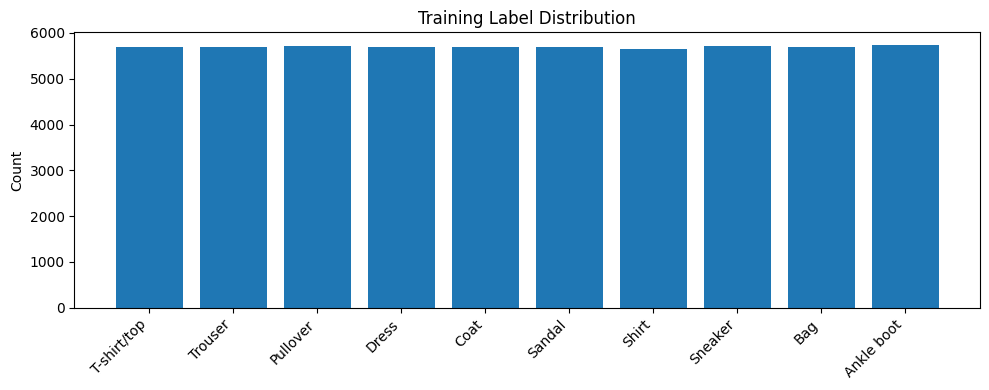

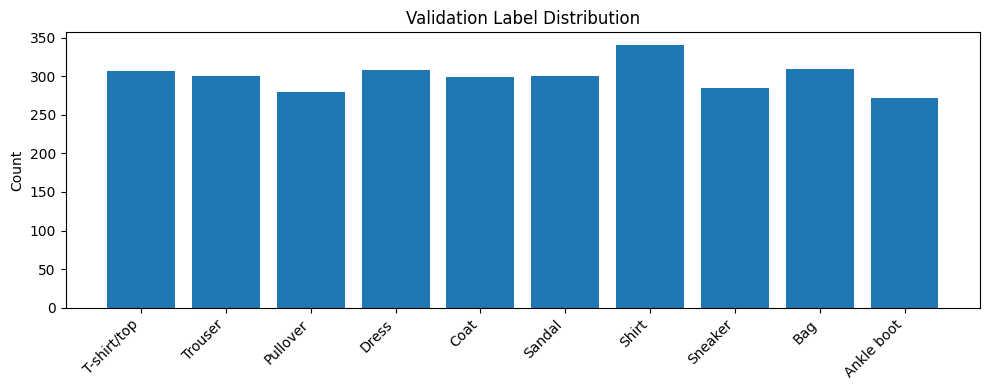

In [8]:

def plot_label_distribution(df: pd.DataFrame, title: str) -> None:
    counts = df["label"].value_counts().sort_index()
    labels = [CLASS_NAMES[i] for i in counts.index]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, counts.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_label_distribution(train_split_df, "Training Label Distribution")
plot_label_distribution(val_split_df, "Validation Label Distribution")

### Question 1

The training and validation distributions are similar, which is consistent with a random split from the same source data.


## Arrays for modeling

The next step separates pixel values and labels so the same data can be used for both model types.


In [9]:

X_train, y_train = data_manager.separate_features_and_labels(train_split_df)
X_val, y_val = data_manager.separate_features_and_labels(val_split_df)
X_test, y_test = data_manager.separate_features_and_labels(test_df)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (57000, 784)
X_val shape: (3000, 784)
X_test shape: (10000, 784)
y_train shape: (57000,)
y_val shape: (3000,)
y_test shape: (10000,)


# Dataset classes

The fully connected model uses flattened pixel vectors, while the CNN uses reshaped `1 x 28 x 28` image tensors.


In [10]:
class FashionTabularDataset(Dataset):
    """Dataset for the fully connected model using flattened pixel vectors."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        # Scale pixel values to the 0-1 range before converting to tensors.
        self.X = torch.tensor(X / 255.0, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


class FashionImageDataset(Dataset):
    """Dataset for the CNN using grayscale image tensors of shape (1, 28, 28)."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        # The CNN expects a channel dimension, so reshape to (N, 1, 28, 28).
        X_scaled = X / 255.0
        X_images = X_scaled.reshape(-1, 1, 28, 28)

        self.X = torch.tensor(X_images, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


In [11]:

class DataLoaderFactory:
    """Create PyTorch DataLoaders for a given Dataset type."""

    def __init__(self, config: ProjectConfig):
        self.config = config

    def build_loaders(
        self,
        dataset_class,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
        X_test: np.ndarray,
        y_test: np.ndarray
    ) -> Dict[str, DataLoader]:
        train_dataset = dataset_class(X_train, y_train)
        val_dataset = dataset_class(X_val, y_val)
        test_dataset = dataset_class(X_test, y_test)

        # Shuffle only the training set so batches change across epochs.
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False
        )

        return {
            "train": train_loader,
            "val": val_loader,
            "test": test_loader
        }

# Question 2(a): Fully connected network


In [12]:

class FullyConnectedNet(nn.Module):
    """Fully connected neural network for flattened Fashion-MNIST pixels."""

    def __init__(self, input_dim: int = 784, hidden1: int = 32, hidden2: int = 16, num_classes: int = 10):
        super().__init__()
        self.network = nn.Sequential(
            # First hidden layer: 784 inputs to 32 neurons.
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            # Second hidden layer: 32 inputs to 16 neurons.
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            # Output layer: one score for each clothing class.
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

## Training utilities

The same training helper is used for both models.


In [13]:

class Trainer:
    """Generic training helper for classification models in PyTorch."""

    def __init__(self, model: nn.Module, config: ProjectConfig):
        self.model = model.to(config.device)
        self.config = config
        # Cross-entropy is standard for multi-class classification.
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config.learning_rate)
        self.history = {
            "train_loss": [],
            "train_accuracy": [],
            "val_loss": [],
            "val_accuracy": []
        }

    def _run_one_epoch(self, loader: DataLoader, training: bool) -> Tuple[float, float]:
        # Switch between train/eval mode so dropout or batchnorm would behave correctly.
        if training:
            self.model.train()
        else:
            self.model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        context = torch.enable_grad() if training else torch.no_grad()
        with context:
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.config.device)
                y_batch = y_batch.to(self.config.device)

                if training:
                    self.optimizer.zero_grad()

                # The model returns raw class scores for each image.
                logits = self.model(X_batch)
                loss = self.criterion(logits, y_batch)

                if training:
                    loss.backward()
                    self.optimizer.step()

                running_loss += loss.item() * X_batch.size(0)
                predictions = torch.argmax(logits, dim=1)
                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        average_loss = running_loss / total
        accuracy = correct / total
        return average_loss, accuracy

    def fit(self, train_loader: DataLoader, val_loader: DataLoader, max_epochs: int) -> Dict[str, List[float]]:
        best_val_loss = float("inf")
        best_model_state = copy.deepcopy(self.model.state_dict())
        epochs_without_improvement = 0

        # Keep the best model seen on the validation set.
        for epoch in range(1, max_epochs + 1):
            train_loss, train_acc = self._run_one_epoch(train_loader, training=True)
            val_loss, val_acc = self._run_one_epoch(val_loader, training=False)

            self.history["train_loss"].append(train_loss)
            self.history["train_accuracy"].append(train_acc)
            self.history["val_loss"].append(val_loss)
            self.history["val_accuracy"].append(val_acc)

            print(
                f"Epoch {epoch:02d}/{max_epochs} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(self.model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.config.patience:
                print(f"Early stopping triggered after epoch {epoch}.")
                break

        self.model.load_state_dict(best_model_state)
        return self.history

In [14]:

def plot_training_history(history: Dict[str, List[float]], title_prefix: str) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Loss by Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_accuracy"], label="Training Accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Accuracy by Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:

fc_loader_factory = DataLoaderFactory(CONFIG)
fc_loaders = fc_loader_factory.build_loaders(
    FashionTabularDataset,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

fc_model = FullyConnectedNet()
fc_trainer = Trainer(fc_model, CONFIG)
fc_history = fc_trainer.fit(fc_loaders["train"], fc_loaders["val"], CONFIG.max_epochs_fc)

Epoch 01/25 | Train Loss: 0.7931 | Train Acc: 0.7358 | Val Loss: 0.4987 | Val Acc: 0.8293
Epoch 02/25 | Train Loss: 0.4772 | Train Acc: 0.8359 | Val Loss: 0.4485 | Val Acc: 0.8427
Epoch 03/25 | Train Loss: 0.4356 | Train Acc: 0.8489 | Val Loss: 0.4275 | Val Acc: 0.8453
Epoch 04/25 | Train Loss: 0.4114 | Train Acc: 0.8571 | Val Loss: 0.4370 | Val Acc: 0.8423
Epoch 05/25 | Train Loss: 0.3954 | Train Acc: 0.8618 | Val Loss: 0.3991 | Val Acc: 0.8553
Epoch 06/25 | Train Loss: 0.3835 | Train Acc: 0.8645 | Val Loss: 0.3879 | Val Acc: 0.8570
Epoch 07/25 | Train Loss: 0.3694 | Train Acc: 0.8687 | Val Loss: 0.4058 | Val Acc: 0.8543
Epoch 08/25 | Train Loss: 0.3628 | Train Acc: 0.8699 | Val Loss: 0.3879 | Val Acc: 0.8560
Epoch 09/25 | Train Loss: 0.3526 | Train Acc: 0.8748 | Val Loss: 0.3907 | Val Acc: 0.8600
Epoch 10/25 | Train Loss: 0.3468 | Train Acc: 0.8770 | Val Loss: 0.3727 | Val Acc: 0.8617
Epoch 11/25 | Train Loss: 0.3416 | Train Acc: 0.8782 | Val Loss: 0.4019 | Val Acc: 0.8537
Epoch 12/2

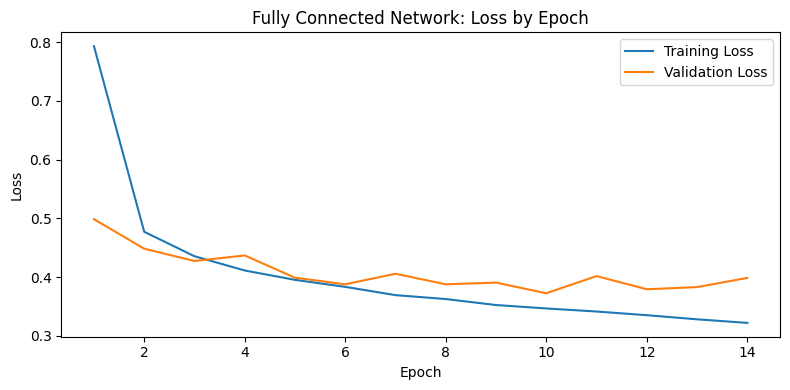

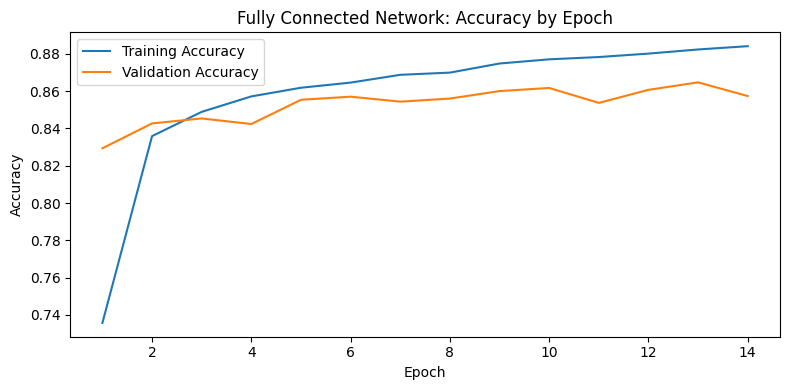

In [16]:

plot_training_history(fc_history, "Fully Connected Network")

In [17]:

def summarize_final_epoch(history: Dict[str, List[float]]) -> pd.DataFrame:
    summary = pd.DataFrame({
        "metric": ["training_loss", "training_accuracy", "validation_loss", "validation_accuracy"],
        "value": [
            history["train_loss"][-1],
            history["train_accuracy"][-1],
            history["val_loss"][-1],
            history["val_accuracy"][-1],
        ]
    })
    return summary


display(summarize_final_epoch(fc_history))

,metric,value
0,training_loss,0.322236
1,training_accuracy,0.884070
2,validation_loss,0.398789
3,validation_accuracy,0.857333


### Question 2(a)

The table and learning curves summarize the fully connected model training results.


# Question 2(b): Test-set evaluation for the fully connected network


In [18]:

class ClassificationEvaluator:
    """Evaluate a trained classification model on a DataLoader."""

    def __init__(self, model: nn.Module, config: ProjectConfig):
        self.model = model.to(config.device)
        self.config = config

    def predict(self, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
        self.model.eval()
        all_preds = []
        all_targets = []

        # No gradients are needed during evaluation.
        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.config.device)
                logits = self.model(X_batch)
                preds = torch.argmax(logits, dim=1).cpu().numpy()

                all_preds.append(preds)
                all_targets.append(y_batch.numpy())

        y_true = np.concatenate(all_targets)
        y_pred = np.concatenate(all_preds)
        return y_true, y_pred

    @staticmethod
    def overall_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return float((y_true == y_pred).mean())

    @staticmethod
    def per_class_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
        rows = []
        for class_id in sorted(CLASS_NAMES.keys()):
            mask = (y_true == class_id)
            accuracy = (y_pred[mask] == y_true[mask]).mean()
            rows.append({
                "label": class_id,
                "class_name": CLASS_NAMES[class_id],
                "accuracy": accuracy
            })
        return pd.DataFrame(rows)

    @staticmethod
    def compute_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        return confusion_matrix(y_true, y_pred, labels=list(CLASS_NAMES.keys()))

    @staticmethod
    def most_confused_pair(cm: np.ndarray) -> Tuple[int, int, int]:
        # Ignore the diagonal so only misclassifications are considered here.
        cm_no_diag = cm.copy()
        np.fill_diagonal(cm_no_diag, 0)
        i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
        return i, j, cm_no_diag[i, j]

    @staticmethod
    def plot_confusion_matrix(cm: np.ndarray, title: str) -> None:
        fig, ax = plt.subplots(figsize=(9, 7))
        image = ax.imshow(cm, cmap="Blues")
        fig.colorbar(image, ax=ax)
        tick_labels = [CLASS_NAMES[i] for i in range(len(CLASS_NAMES))]
        ax.set_xticks(range(len(tick_labels)))
        ax.set_yticks(range(len(tick_labels)))
        ax.set_xticklabels(tick_labels, rotation=45, ha="right")
        ax.set_yticklabels(tick_labels)
        for row in range(cm.shape[0]):
            for col in range(cm.shape[1]):
                ax.text(col, row, str(cm[row, col]), ha="center", va="center", color="black")
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_title(title)
        plt.tight_layout()
        plt.show()


Fully connected test accuracy: 0.8610


,label,class_name,accuracy
0,0,T-shirt/top,0.803
1,1,Trouser,0.959
2,2,Pullover,0.727
3,3,Dress,0.888
4,4,Coat,0.793
5,5,Sandal,0.952
6,6,Shirt,0.641
7,7,Sneaker,0.939
8,8,Bag,0.967
9,9,Ankle boot,0.941


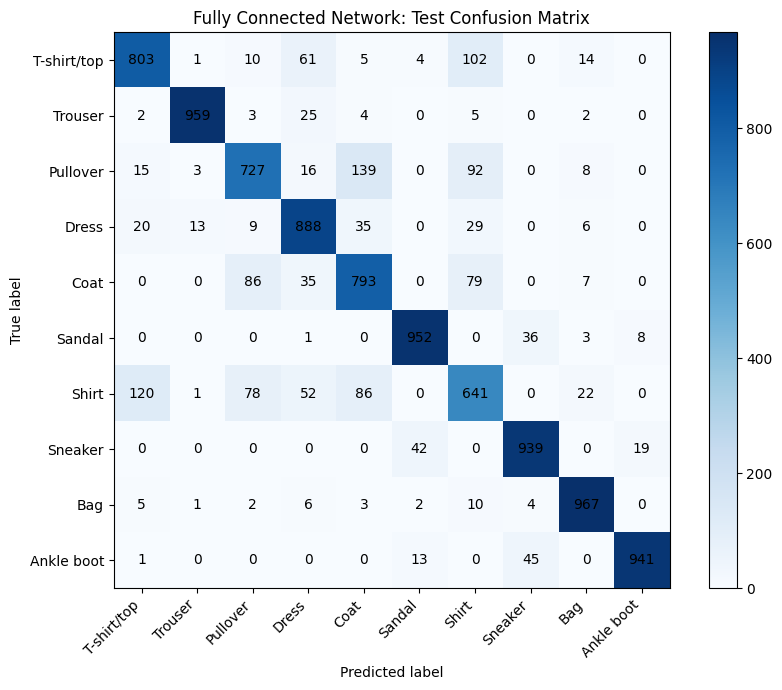

Most frequently confused classes: Pullover -> Coat (139 images)


In [19]:

fc_evaluator = ClassificationEvaluator(fc_trainer.model, CONFIG)
fc_y_true, fc_y_pred = fc_evaluator.predict(fc_loaders["test"])

fc_test_accuracy = fc_evaluator.overall_accuracy(fc_y_true, fc_y_pred)
fc_per_class_acc = fc_evaluator.per_class_accuracy(fc_y_true, fc_y_pred)
fc_cm = fc_evaluator.compute_confusion_matrix(fc_y_true, fc_y_pred)
fc_most_confused = fc_evaluator.most_confused_pair(fc_cm)

print(f"Fully connected test accuracy: {fc_test_accuracy:.4f}")
display(fc_per_class_acc)
fc_evaluator.plot_confusion_matrix(fc_cm, "Fully Connected Network: Test Confusion Matrix")

print(
    "Most frequently confused classes:",
    f"{CLASS_NAMES[fc_most_confused[0]]} -> {CLASS_NAMES[fc_most_confused[1]]}",
    f"({fc_most_confused[2]} images)"
)

### Question 2(b)

The outputs above report test accuracy, per-class accuracy, and the most common confusion for the fully connected model.


# Question 3(a): Treat the predictors as images

Each observation is reshaped into a `28 x 28` grayscale image, and one example from each class is displayed below.


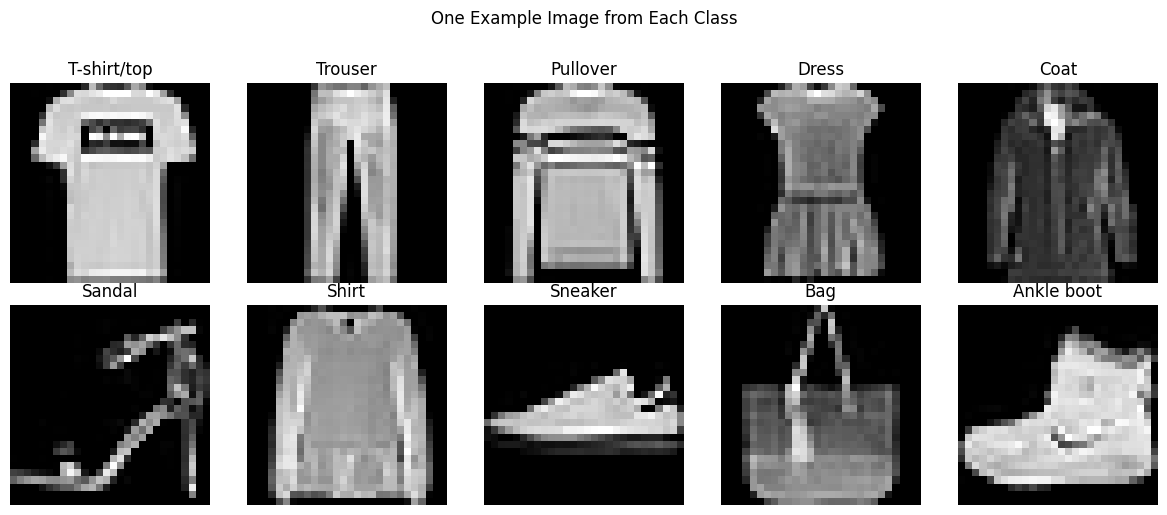

In [20]:

def display_one_image_per_class(X: np.ndarray, y: np.ndarray) -> None:
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()

    for class_id in sorted(CLASS_NAMES.keys()):
        idx = np.where(y == class_id)[0][0]
        image = X[idx].reshape(28, 28)

        axes[class_id].imshow(image, cmap="gray")
        axes[class_id].set_title(CLASS_NAMES[class_id])
        axes[class_id].axis("off")

    plt.suptitle("One Example Image from Each Class", y=1.02)
    plt.tight_layout()
    plt.show()


display_one_image_per_class(X_train, y_train)

# Question 3(b): CNN model


In [21]:
class SimpleCNN(nn.Module):
    """CNN with the exact architecture required by the project statement."""

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.features = nn.Sequential(
            # First convolution block: 8 learned filters, then downsample.
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Second convolution block: expand to 16 feature maps.
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            # Flatten the feature maps before the dense layers.
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


In [22]:

cnn_loader_factory = DataLoaderFactory(CONFIG)
cnn_loaders = cnn_loader_factory.build_loaders(
    FashionImageDataset,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

cnn_model = SimpleCNN()
cnn_trainer = Trainer(cnn_model, CONFIG)
cnn_history = cnn_trainer.fit(cnn_loaders["train"], cnn_loaders["val"], CONFIG.max_epochs_cnn)

Epoch 01/25 | Train Loss: 0.7554 | Train Acc: 0.7278 | Val Loss: 0.4764 | Val Acc: 0.8263
Epoch 02/25 | Train Loss: 0.4500 | Train Acc: 0.8360 | Val Loss: 0.4046 | Val Acc: 0.8493
Epoch 03/25 | Train Loss: 0.3912 | Train Acc: 0.8589 | Val Loss: 0.3884 | Val Acc: 0.8583
Epoch 04/25 | Train Loss: 0.3570 | Train Acc: 0.8709 | Val Loss: 0.3598 | Val Acc: 0.8690
Epoch 05/25 | Train Loss: 0.3326 | Train Acc: 0.8805 | Val Loss: 0.3336 | Val Acc: 0.8733
Epoch 06/25 | Train Loss: 0.3162 | Train Acc: 0.8866 | Val Loss: 0.3212 | Val Acc: 0.8770
Epoch 07/25 | Train Loss: 0.3008 | Train Acc: 0.8928 | Val Loss: 0.3205 | Val Acc: 0.8790
Epoch 08/25 | Train Loss: 0.2920 | Train Acc: 0.8946 | Val Loss: 0.3028 | Val Acc: 0.8883
Epoch 09/25 | Train Loss: 0.2829 | Train Acc: 0.8986 | Val Loss: 0.2938 | Val Acc: 0.8853
Epoch 10/25 | Train Loss: 0.2739 | Train Acc: 0.9017 | Val Loss: 0.3068 | Val Acc: 0.8863
Epoch 11/25 | Train Loss: 0.2651 | Train Acc: 0.9035 | Val Loss: 0.2836 | Val Acc: 0.8930
Epoch 12/2

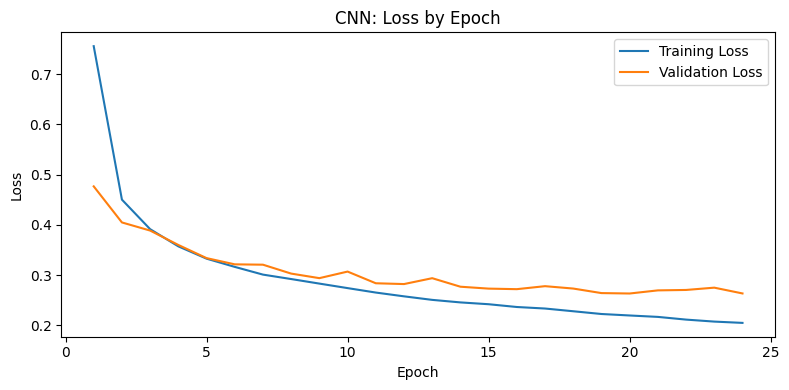

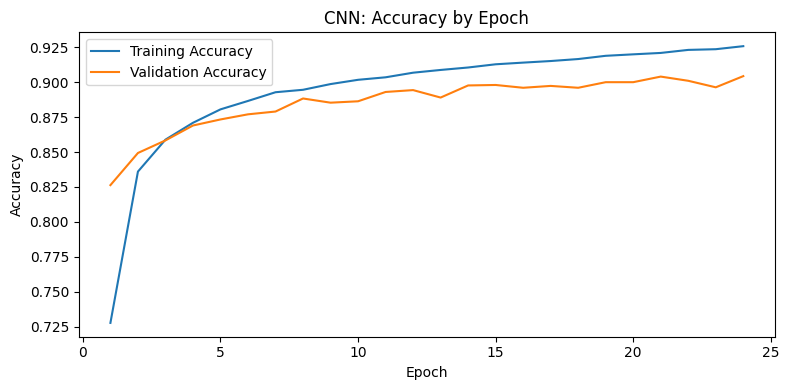

,metric,value
0,training_loss,0.204714
1,training_accuracy,0.925772
2,validation_loss,0.263299
3,validation_accuracy,0.904333


In [23]:

plot_training_history(cnn_history, "CNN")
display(summarize_final_epoch(cnn_history))

### Question 3(b)

The table and learning curves summarize the CNN training results.


# Question 3(c): Test-set evaluation for the CNN


CNN test accuracy: 0.9049


,label,class_name,accuracy
0,0,T-shirt/top,0.865
1,1,Trouser,0.980
2,2,Pullover,0.838
3,3,Dress,0.904
4,4,Coat,0.911
5,5,Sandal,0.986
6,6,Shirt,0.671
7,7,Sneaker,0.950
8,8,Bag,0.979
9,9,Ankle boot,0.965


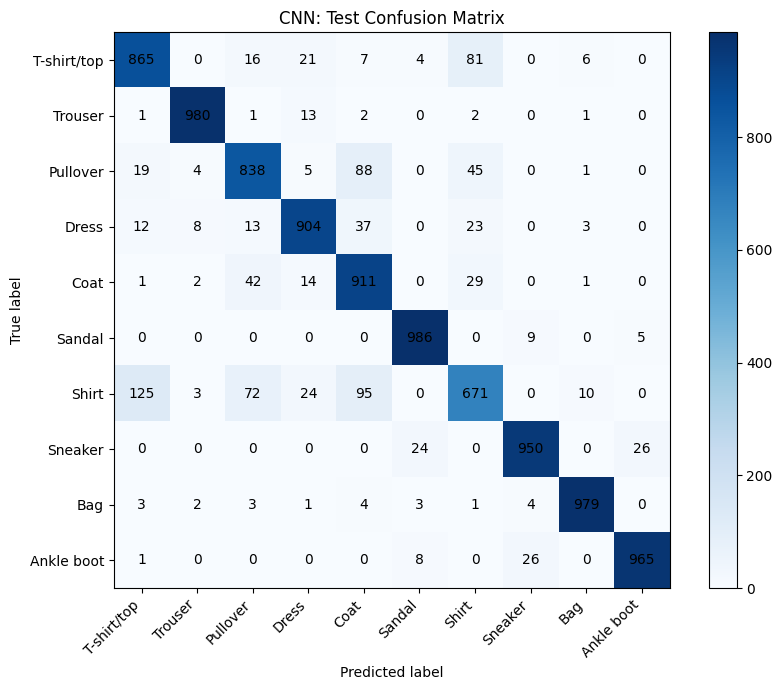

Most frequently confused classes: Shirt -> T-shirt/top (125 images)


In [24]:

cnn_evaluator = ClassificationEvaluator(cnn_trainer.model, CONFIG)
cnn_y_true, cnn_y_pred = cnn_evaluator.predict(cnn_loaders["test"])

cnn_test_accuracy = cnn_evaluator.overall_accuracy(cnn_y_true, cnn_y_pred)
cnn_per_class_acc = cnn_evaluator.per_class_accuracy(cnn_y_true, cnn_y_pred)
cnn_cm = cnn_evaluator.compute_confusion_matrix(cnn_y_true, cnn_y_pred)
cnn_most_confused = cnn_evaluator.most_confused_pair(cnn_cm)

print(f"CNN test accuracy: {cnn_test_accuracy:.4f}")
display(cnn_per_class_acc)
cnn_evaluator.plot_confusion_matrix(cnn_cm, "CNN: Test Confusion Matrix")

print(
    "Most frequently confused classes:",
    f"{CLASS_NAMES[cnn_most_confused[0]]} -> {CLASS_NAMES[cnn_most_confused[1]]}",
    f"({cnn_most_confused[2]} images)"
)

### Hypothesis for the most-confused classes

The most-confused pair is likely visually similar at this resolution. In 28 x 28 grayscale images, classes with similar outlines and texture are harder to separate.


# Question 4(a): Parameter-count check

The trainable parameter counts for both models are compared directly below.


In [25]:

def count_trainable_parameters(model: nn.Module) -> int:
    # Count only weights and biases that are updated during training.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


fc_param_count = count_trainable_parameters(fc_model)
cnn_param_count = count_trainable_parameters(cnn_model)

parameter_comparison = pd.DataFrame({
    "model": ["Fully Connected Network", "CNN"],
    "trainable_parameters": [fc_param_count, cnn_param_count]
})
display(parameter_comparison)

difference = abs(fc_param_count - cnn_param_count)
print(f"Absolute parameter-count difference: {difference}")

,model,trainable_parameters
0,Fully Connected Network,25818
1,CNN,26698


Absolute parameter-count difference: 880


### Question 4(a)

The two models have parameter counts in the same general range, so the comparison is not driven by a large size difference.


# Question 4(b): Why should the CNN outperform the fully connected network on image data?

Under a similar parameter budget, the CNN should perform better because it uses the spatial structure of the image. Convolutional filters detect local patterns, weight sharing reduces redundant parameters, and pooling helps retain the strongest features while reducing spatial size. A fully connected network treats the image as a flat vector, so it loses much of that structure.


# Final comparison summary


In [26]:

# Put the main results side by side for a direct comparison.
final_comparison = pd.DataFrame({
    "model": ["Fully Connected Network", "CNN"],
    "train_accuracy": [fc_history["train_accuracy"][-1], cnn_history["train_accuracy"][-1]],
    "validation_accuracy": [fc_history["val_accuracy"][-1], cnn_history["val_accuracy"][-1]],
    "test_accuracy": [fc_test_accuracy, cnn_test_accuracy],
    "parameters": [fc_param_count, cnn_param_count]
})
display(final_comparison)

,model,train_accuracy,validation_accuracy,test_accuracy,parameters
0,Fully Connected Network,0.884070,0.857333,0.8610,25818
1,CNN,0.925772,0.904333,0.9049,26698


# Conclusion

The notebook completes the required data split, training, evaluation, and parameter comparison for the Fashion-MNIST models.
